**Data sources:**
- Digits `0–9`: MNIST (60,000 images, 28×28)
- Operators `+` `-` `×` `÷`: Kaggle *Handwritten Math Symbols* dataset

**Steps:**
1. Download the Kaggle dataset and set `DATASET_PATH` below
2. Run all cells
3. `model.keras` is saved → run `streamlit run equation_solver.py`


In [78]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import shuffle

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 1. Configuration

In [79]:
# ─── SET THIS to the extracted dataset folder ───────────────────────
# After downloading from Kaggle, extract the zip.
# The folder should contain sub-folders: 0,1,2,...,9,+,-,times,div
DATASET_PATH = "./dataset"   # <-- change if needed
import os
print(os.getcwd())
# ────────────────────────────────────────────────────────────────────

# Label mapping  (must match equation_solver.py)
# Classes 0-9  → digits
# Class  10    → +
# Class  11    → -
# Class  12    → * (times)
# Class  13    → / (div)
OPERATOR_FOLDERS = {
    "add": 10,   # +
    "sub": 11,   # -
    "mul": 12,   # ×
    "div": 13,   # ÷
}
NUM_CLASSES = 14
IMG_SIZE    = 28   # resize everything to 28×28 (same as MNIST)


/Users/abhirupsain/Documents/TU_DRESDEN/STIPT/Courses/AI/AI_Project


## 2. Load Operator Images from Kaggle Dataset

In [80]:
def load_operator_images(dataset_path, operator_folders, img_size=28):
    X, y = [], []
    for folder_name, label in operator_folders.items():
        folder_path = os.path.join(dataset_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue
        files = [f for f in os.listdir(folder_path)
                 if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        print(f"  {folder_name:>6}  (label {label}): {len(files)} images")
        for fname in files:
            img = cv2.imread(os.path.join(folder_path, fname),
                             cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            # Invert if background is dark (make background white, ink black)
            if img.mean() < 127:
                img = 255 - img
            img = cv2.resize(img, (img_size, img_size),
                             interpolation=cv2.INTER_AREA)
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

print("Loading operator images …")
X_ops, y_ops = load_operator_images(DATASET_PATH, OPERATOR_FOLDERS)
print(f"Total operator images: {len(X_ops)}")


Loading operator images …
     add  (label 10): 596 images
     sub  (label 11): 655 images
     mul  (label 12): 577 images
     div  (label 13): 618 images
Total operator images: 2446


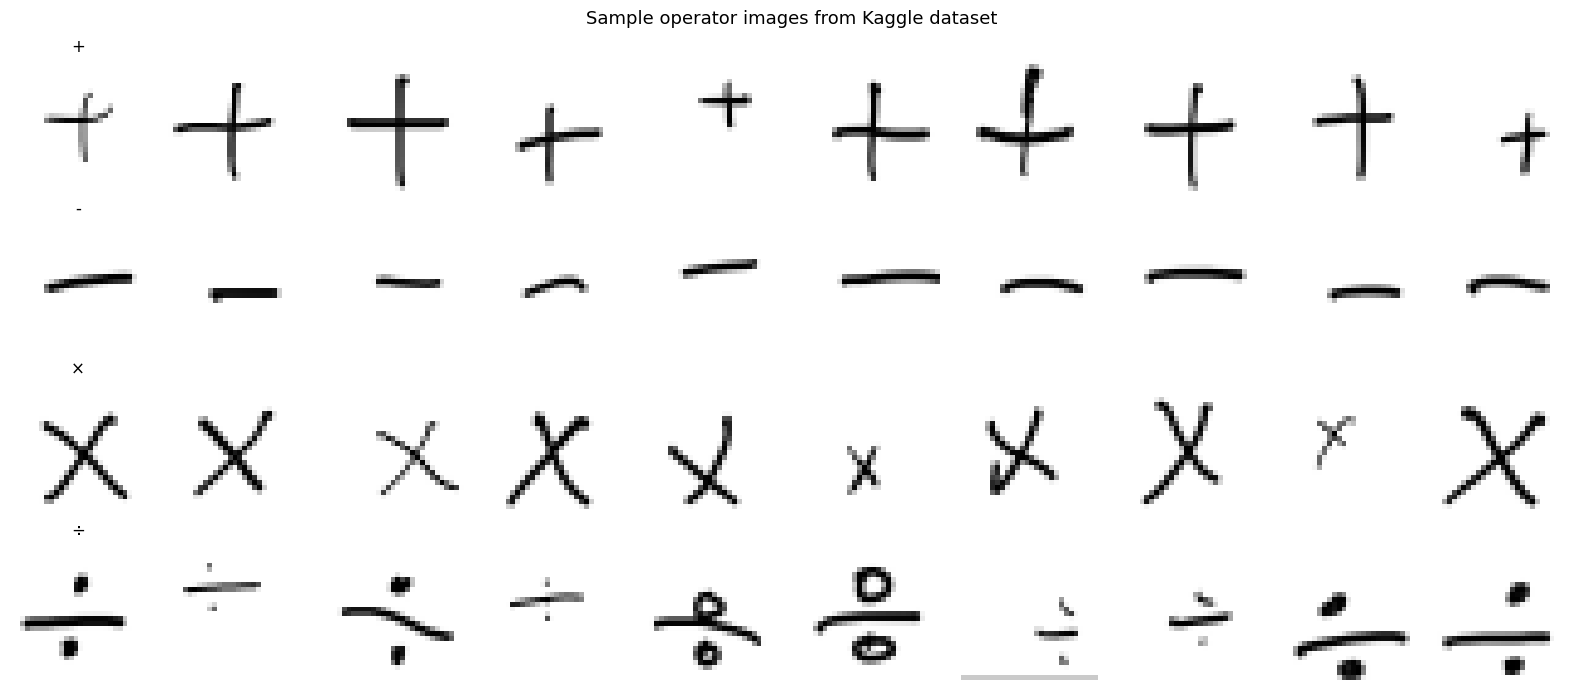

In [81]:
label_names = {10:"+", 11:"-", 12:"×", 13:"÷"}

fig, axes = plt.subplots(4, 10, figsize=(16, 7))
for row, (lbl, name) in enumerate(label_names.items()):
    samples = X_ops[y_ops == lbl][:10]
    for col, ax in enumerate(axes[row]):
        if col < len(samples):
            ax.imshow(samples[col], cmap="gray")
        ax.set_title(name if col == 0 else "", fontsize=12)
        ax.axis("off")
plt.suptitle("Sample operator images from Kaggle dataset", fontsize=13)
plt.tight_layout()
plt.show()


## 3. Load MNIST Digits

In [82]:
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()
print(f"MNIST train: {X_train_mnist.shape}  test: {X_test_mnist.shape}")


MNIST train: (60000, 28, 28)  test: (10000, 28, 28)


## 4. Combine Digits + Operators

In [83]:
# Split operator images into train (80%) / test (20%)
from sklearn.model_selection import train_test_split

X_ops_tr, X_ops_te, y_ops_tr, y_ops_te = train_test_split(
    X_ops, y_ops, test_size=0.2, random_state=42, stratify=y_ops
)

# Stack with MNIST
X_train_all = np.concatenate([X_train_mnist, X_ops_tr], axis=0)
y_train_all = np.concatenate([y_train_mnist, y_ops_tr], axis=0)
X_test_all  = np.concatenate([X_test_mnist,  X_ops_te], axis=0)
y_test_all  = np.concatenate([y_test_mnist,  y_ops_te], axis=0)

# Shuffle
X_train_all, y_train_all = shuffle(X_train_all, y_train_all, random_state=42)

print(f"Combined train : {X_train_all.shape}")
print(f"Combined test  : {X_test_all.shape}")
print("Class counts (train):", {c: int((y_train_all==c).sum()) for c in range(14)})


Combined train : (61956, 28, 28)
Combined test  : (10490, 28, 28)
Class counts (train): {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949, 10: 477, 11: 524, 12: 461, 13: 494}


## 5. Preprocess

In [84]:
X_train = X_train_all.reshape(-1, 28, 28, 1) / 255.0
X_test  = X_test_all.reshape(-1,  28, 28, 1) / 255.0
Y_train = to_categorical(y_train_all, NUM_CLASSES)
Y_test  = to_categorical(y_test_all,  NUM_CLASSES)

print("X_train:", X_train.shape, " Y_train:", Y_train.shape)


X_train: (61956, 28, 28, 1)  Y_train: (61956, 14)


## 6. Data Augmentation

In [85]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=5,
)
datagen.fit(X_train)


## 7. Build CNN (14-class)

In [86]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    Flatten(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="softmax"),
], name="math_cnn")

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "math_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,383,374 (9.09 MB)

 Trainable params: 2,382,670 (9.09 MB)

 Non-trainable params: 704 (2.75 KB)

## 8. Train

In [87]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=2, verbose=1),
]

history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=128),
    epochs=25,
    steps_per_epoch=len(X_train) // 128,
    validation_data=(X_test, Y_test),
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.8964 - loss: 0.3512 - val_accuracy: 0.5410 - val_loss: 1.6987 - learning_rate: 0.0010
Epoch 2/25
  1/484 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - accuracy: 0.9609 - loss: 0.1021

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9609 - loss: 0.1021 - val_accuracy: 0.5404 - val_loss: 1.7163 - learning_rate: 0.0010
Epoch 3/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.9599 - loss: 0.1314 - val_accuracy: 0.9828 - val_loss: 0.0517 - learning_rate: 0.0010
Epoch 4/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9453 - loss: 0.1269 - val_accuracy: 0.9827 - val_loss: 0.0520 - learning_rate: 0.0010
Epoch 5/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9674 - loss: 0.1069
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
484/484 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - accuracy: 0.9684 - loss: 0.1025 - val_accuracy: 0.9823 - val_loss: 0.0585 - learning_rate: 0.0010
Epoch 6/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9297 - loss: 0.1761 - val_accuracy: 0.9823 - val_loss: 0.0576 - learning_rate: 5.0000e-04
Epoch 7/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 37s 77ms/step - accuracy: 0.9768 - loss: 0.0755 - v

## 9. Training Curves

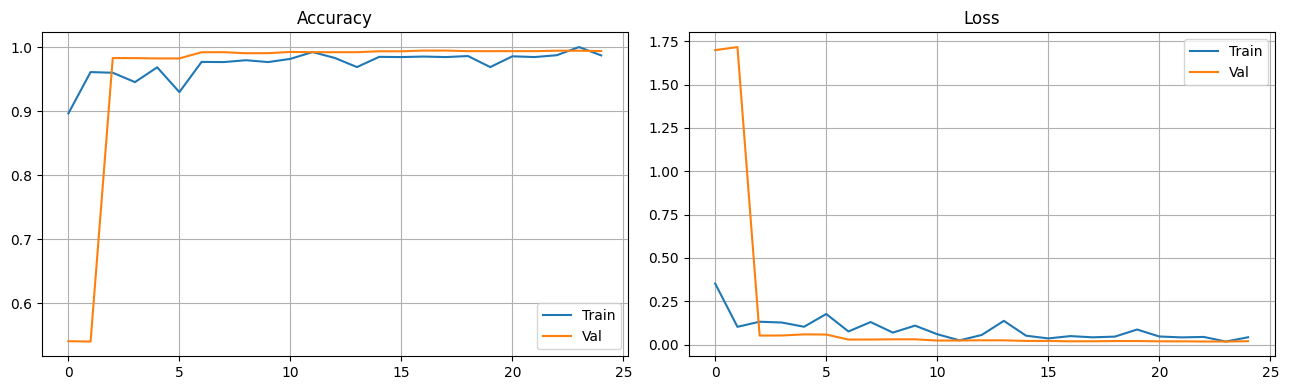

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history.history["accuracy"],     label="Train")
ax1.plot(history.history["val_accuracy"], label="Val")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(True)
ax2.plot(history.history["loss"],     label="Train")
ax2.plot(history.history["val_loss"], label="Val")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()


## 10. Evaluate

In [89]:
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"Overall test accuracy : {acc*100:.2f}%")

# Per-class accuracy
CLASS_NAMES = list("0123456789") + ["+", "-", "×", "÷"]
preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
for c, name in enumerate(CLASS_NAMES):
    mask = y_test_all == c
    if mask.sum() == 0:
        continue
    c_acc = (preds[mask] == c).mean() * 100
    print(f"  {name}: {c_acc:.1f}%  ({mask.sum()} samples)")


Overall test accuracy : 99.43%
  0: 99.5%  (980 samples)
  1: 99.4%  (1135 samples)
  2: 99.5%  (1032 samples)
  3: 99.8%  (1010 samples)
  4: 99.8%  (982 samples)
  5: 99.2%  (892 samples)
  6: 99.1%  (958 samples)
  7: 99.6%  (1028 samples)
  8: 99.5%  (974 samples)
  9: 98.8%  (1009 samples)
  +: 100.0%  (119 samples)
  -: 100.0%  (131 samples)
  ×: 100.0%  (116 samples)
  ÷: 98.4%  (124 samples)


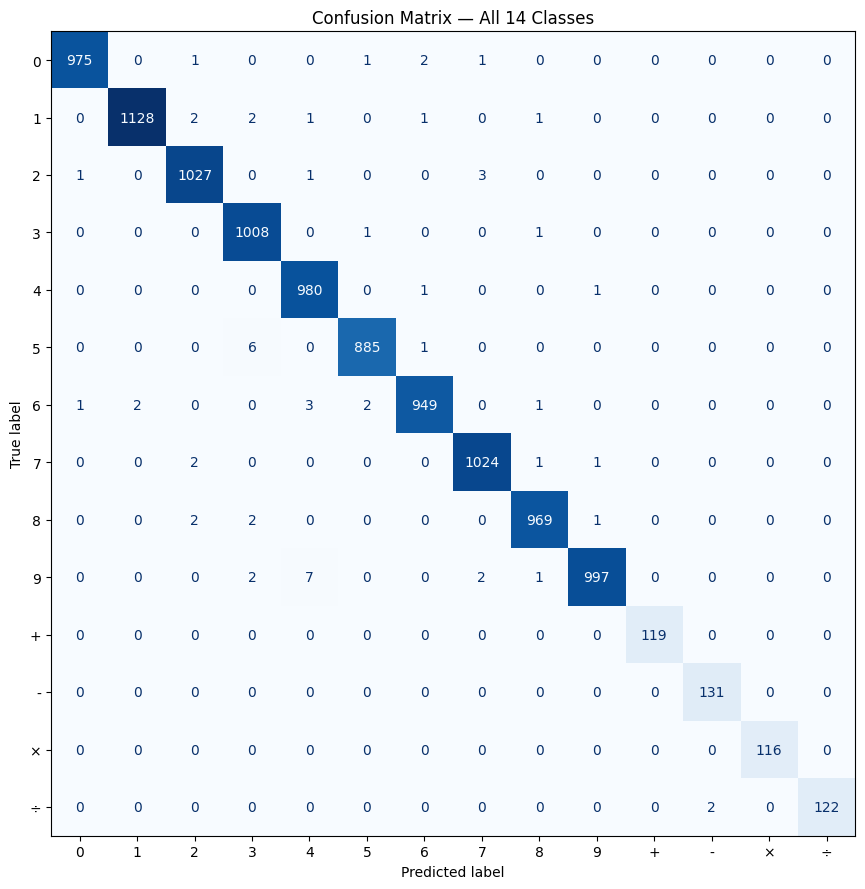

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_all, preds)
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Confusion Matrix — All 14 Classes")
plt.tight_layout(); plt.show()


## 11. Save & Verify

In [92]:
MODEL_PATH = "model.keras"
model.save(MODEL_PATH)
size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Saved to {MODEL_PATH}  ({size_kb:.0f} KB)")

from tensorflow.keras.models import load_model
loaded = load_model(MODEL_PATH)
_, la = loaded.evaluate(X_test, Y_test, verbose=0)
print(f"Round-trip accuracy: {la*100:.2f}%  — ready for the app")


Saved to model.keras  (27981 KB)
Round-trip accuracy: 99.43%  — ready for the app
